# 🛡️ ToxicityShield - Deep Learning for Toxicity Detection

**Projeto completo de detecção de toxicidade em chats de jogos**

Este notebook implementa:
- Preprocessamento de texto (limpeza, tokenização, padding)
- Baselines clássicos (Logistic Regression, SVM)
- Modelos Deep Learning (LSTM, GRU, CNN, Mini-Transformer)
- Avaliação completa com métricas e visualizações

---

## 1. Setup e Imports

In [1]:
# Instalação de dependências (se necessário)
# !pip install torch pandas numpy scikit-learn nltk matplotlib seaborn tqdm

In [2]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Adiciona src ao path
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))
sys.path.insert(0, '../src')

# Adiciona caminho de pastas
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Imports básicos
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Nossos módulos
from data_processing import TextPreprocessor, Vocabulary, pad_sequences, load_kaggle_data
from models import get_model, count_parameters
from training import (
    create_dataloaders, train_model, evaluate, get_full_metrics, print_metrics,
    plot_training_history, plot_confusion_matrix, plot_roc_curves_comparison,
    plot_model_comparison, ToxicityPredictor
)

# Config
plt.style.use('seaborn-v0_8-whitegrid')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")

Device: cpu
PyTorch: 2.9.1+cpu


## 2. Carregar Dataset

### Download do Kaggle:
1. Acesse: https://www.kaggle.com/c/jigsaw-toxic-comment-classification-challenge
2. Baixe `train.csv`
3. Coloque em `data/raw/train.csv`

In [3]:
# Carrega dados
DATA_PATH = '../data/raw/train.csv'

# Usa amostra menor para treino rápido (remova para dataset completo)
SAMPLE_SIZE = 50000  # None para usar tudo

df = load_kaggle_data(DATA_PATH, sample_size=SAMPLE_SIZE)
df.head()

Dataset carregado: 50000 amostras
Distribuição: {0: 44907, 1: 5093}


,id,text,toxic,severe_toxic,obscene,threat,insult,identity_hate,toxic_binary
119105,7ca72b5b9c688e9e,"Geez, are you forgetful! We've already discus...",0,0,0,0,0,0,0
131631,c03f72fd8f8bf54f,Carioca RFA \n\nThanks for your support on my ...,0,0,0,0,0,0,0
125326,9e5b8e8fc1ff2e84,"""\n\n Birthday \n\nNo worries, It's what I do ...",0,0,0,0,0,0,0
111256,5332799e706665a6,Pseudoscience category? \n\nI'm assuming that ...,0,0,0,0,0,0,0
83590,dfa7d8f0b4366680,"(and if such phrase exists, it would be provid...",0,0,0,0,0,0,0


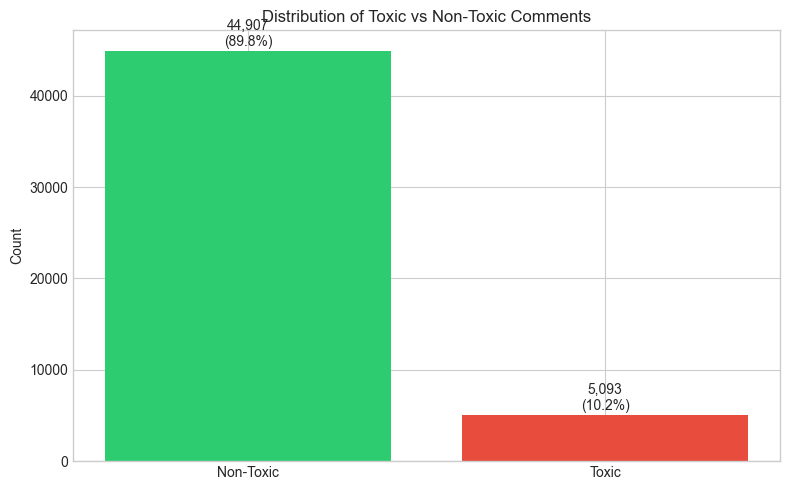

In [4]:
# Visualiza distribuição
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['toxic_binary'].value_counts()
bars = ax.bar(['Non-Toxic', 'Toxic'], counts.values, color=['#2ecc71', '#e74c3c'])
ax.set_ylabel('Count')
ax.set_title('Distribution of Toxic vs Non-Toxic Comments')

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

## 3. Preprocessamento

In [5]:
# Inicializa preprocessador
preprocessor = TextPreprocessor(remove_stopwords=False)

# Processa textos
df = preprocessor.process_dataframe(df, 'text')

# Remove textos vazios após limpeza
df = df[df['cleaned_text'].str.len() > 0].reset_index(drop=True)

print(f"Dataset após limpeza: {len(df)} amostras")
print(f"\nExemplo de limpeza:")
print(f"Original: {df['text'].iloc[0][:100]}...")
print(f"Limpo:    {df['cleaned_text'].iloc[0][:100]}...")

Dataset após limpeza: 49995 amostras

Exemplo de limpeza:
Original: Geez, are you forgetful!  We've already discussed why Marx  was  not an anarchist, i.e. he wanted to...
Limpo:    geez are you forgetful we ve already discussed why marx was not an anarchist i e he wanted to use a ...


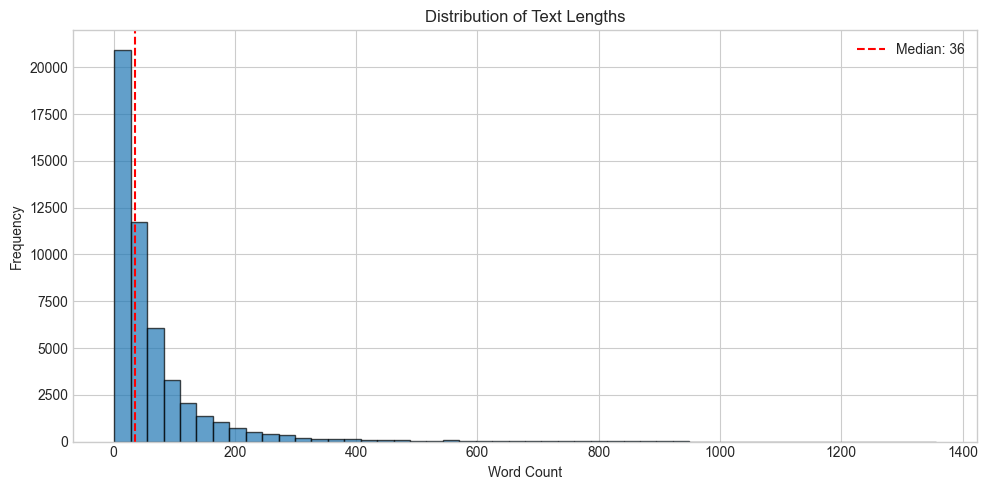

In [6]:
# Distribuição de tamanho dos textos
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(df['word_count'].median(), color='red', linestyle='--', label=f"Median: {df['word_count'].median():.0f}")
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Text Lengths')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Constrói vocabulário
MAX_VOCAB_SIZE = 20000
MIN_FREQ = 3

vocab = Vocabulary(max_vocab_size=MAX_VOCAB_SIZE, min_freq=MIN_FREQ)
vocab.build_vocab(df['cleaned_text'].tolist())

Vocabulário construído: 20000 palavras


In [8]:
# Converte textos para sequências e aplica padding
MAX_LEN = 150  # Baseado na distribuição de tamanhos

sequences = [vocab.text_to_sequence(text) for text in df['cleaned_text']]
X = pad_sequences(sequences, MAX_LEN)
y = df['toxic_binary'].values

print(f"Shape X: {X.shape}")
print(f"Shape y: {y.shape}")

Shape X: (49995, 150)
Shape y: (49995,)


In [9]:
# Split train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 34996 | Val: 7499 | Test: 7500


## 4. Baselines Clássicos (TF-IDF + Logistic Regression / SVM)

In [10]:
# Para baselines, usamos TF-IDF nos textos originais limpos
texts_train = df.iloc[:len(X_train)]['cleaned_text'].values
texts_val = df.iloc[len(X_train):len(X_train)+len(X_val)]['cleaned_text'].values
texts_test = df.iloc[len(X_train)+len(X_val):]['cleaned_text'].values

# TF-IDF
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(texts_train)
X_val_tfidf = tfidf.transform(texts_val)
X_test_tfidf = tfidf.transform(texts_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")

TF-IDF shape: (34996, 10000)


In [11]:
# Logistic Regression
print("Treinando Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

lr_probs = lr_model.predict_proba(X_test_tfidf)[:, 1]
lr_metrics = get_full_metrics(y_test, lr_probs)
print_metrics(lr_metrics, "Logistic Regression")

Treinando Logistic Regression...

 Logistic Regression - Resultados
  Accuracy:  0.6691
  Precision: 0.0960
  Recall:    0.2670
  F1-Score:  0.1412
  ROC-AUC:   0.4897


In [12]:
# SVM
print("Treinando SVM...")
svm_model = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)
svm_model.fit(X_train_tfidf, y_train)

# SVM não tem predict_proba, usamos decision_function
svm_scores = svm_model.decision_function(X_test_tfidf)
# Normaliza para [0, 1]
svm_probs = 1 / (1 + np.exp(-svm_scores))

svm_metrics = get_full_metrics(y_test, svm_probs)
print_metrics(svm_metrics, "SVM")

Treinando SVM...

 SVM - Resultados
  Accuracy:  0.6847
  Precision: 0.0983
  Recall:    0.2565
  F1-Score:  0.1422
  ROC-AUC:   0.4971


## 5. Modelos Deep Learning

In [13]:
# Cria DataLoaders
BATCH_SIZE = 64

train_loader, val_loader, test_loader = create_dataloaders(
    X_train, X_val, X_test, y_train, y_val, y_test, batch_size=BATCH_SIZE
)

In [14]:
# Configurações de treinamento
VOCAB_SIZE = len(vocab)
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
EPOCHS = 15
LEARNING_RATE = 0.001

# Dicionário para guardar resultados
all_results = {
    'Logistic Regression': lr_metrics,
    'SVM': svm_metrics
}
all_probs = {
    'Logistic Regression': (y_test, lr_probs),
    'SVM': (y_test, svm_probs)
}

### 5.1 LSTM

In [15]:
print("="*50)
print("Treinando LSTM...")
print("="*50)

lstm_model = get_model('lstm', VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM)
print(f"Parâmetros: {count_parameters(lstm_model):,}")

lstm_history = train_model(
    lstm_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE
)

Treinando LSTM...
Parâmetros: 3,236,226
Epoch 1/15 | Train Loss: 0.2176, Acc: 0.9262 | Val Loss: 0.1390, Acc: 0.9505
Epoch 2/15 | Train Loss: 0.1201, Acc: 0.9581 | Val Loss: 0.1190, Acc: 0.9573
Epoch 3/15 | Train Loss: 0.0851, Acc: 0.9693 | Val Loss: 0.1270, Acc: 0.9559
Epoch 4/15 | Train Loss: 0.0549, Acc: 0.9812 | Val Loss: 0.1485, Acc: 0.9567
Epoch 5/15 | Train Loss: 0.0333, Acc: 0.9887 | Val Loss: 0.1713, Acc: 0.9532
Epoch 6/15 | Train Loss: 0.0143, Acc: 0.9955 | Val Loss: 0.2008, Acc: 0.9573
Epoch 7/15 | Train Loss: 0.0067, Acc: 0.9982 | Val Loss: 0.2688, Acc: 0.9551
Early stopping na época 7

Treinamento concluído em 793.8s


In [18]:
# Avalia LSTM
criterion = nn.BCEWithLogitsLoss()
_, _, lstm_probs, lstm_labels = evaluate(lstm_model, test_loader, criterion, DEVICE)
lstm_metrics = get_full_metrics(lstm_labels, lstm_probs)
print_metrics(lstm_metrics, "LSTM")

all_results['LSTM'] = lstm_metrics
all_probs['LSTM'] = (lstm_labels, lstm_probs)


 LSTM - Resultados
  Accuracy:  0.9588
  Precision: 0.8785
  Recall:    0.6911
  F1-Score:  0.7736
  ROC-AUC:   0.9570


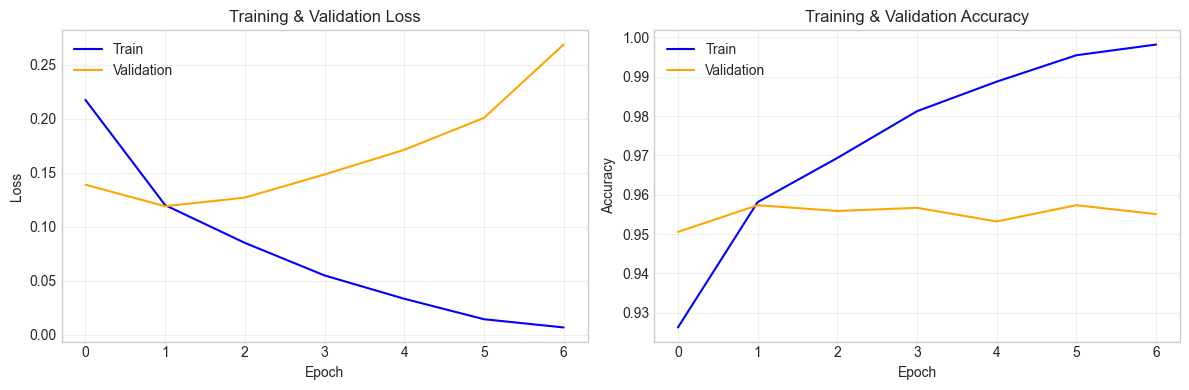

In [20]:
plot_training_history(lstm_history, save_path='../results/lstm_training.png')


### 5.2 GRU

In [ ]:
print("="*50)
print("Treinando GRU...")
print("="*50)

gru_model = get_model('gru', VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, hidden_dim=HIDDEN_DIM)
print(f"Parâmetros: {count_parameters(gru_model):,}")

gru_history = train_model(
    gru_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE
)

Treinando GRU...
Parâmetros: 3,071,105


In [ ]:
_, _, gru_probs, gru_labels = evaluate(gru_model, test_loader, criterion, DEVICE)
gru_metrics = get_full_metrics(gru_labels, gru_probs)
print_metrics(gru_metrics, "GRU")

all_results['GRU'] = gru_metrics
all_probs['GRU'] = (gru_labels, gru_probs)

### 5.3 TextCNN

In [ ]:
print("="*50)
print("Treinando TextCNN...")
print("="*50)

cnn_model = get_model('cnn', VOCAB_SIZE, embedding_dim=EMBEDDING_DIM)
print(f"Parâmetros: {count_parameters(cnn_model):,}")

cnn_history = train_model(
    cnn_model, train_loader, val_loader,
    epochs=EPOCHS, lr=LEARNING_RATE, device=DEVICE
)

In [ ]:
_, _, cnn_probs, cnn_labels = evaluate(cnn_model, test_loader, criterion, DEVICE)
cnn_metrics = get_full_metrics(cnn_labels, cnn_probs)
print_metrics(cnn_metrics, "TextCNN")

all_results['TextCNN'] = cnn_metrics
all_probs['TextCNN'] = (cnn_labels, cnn_probs)

### 5.4 Mini-Transformer

In [ ]:
print("="*50)
print("Treinando Mini-Transformer...")
print("="*50)

transformer_model = get_model('transformer', VOCAB_SIZE, embedding_dim=EMBEDDING_DIM, max_len=MAX_LEN)
print(f"Parâmetros: {count_parameters(transformer_model):,}")

transformer_history = train_model(
    transformer_model, train_loader, val_loader,
    epochs=EPOCHS, lr=0.0005, device=DEVICE  # LR menor para transformer
)

In [ ]:
_, _, transformer_probs, transformer_labels = evaluate(transformer_model, test_loader, criterion, DEVICE)
transformer_metrics = get_full_metrics(transformer_labels, transformer_probs)
print_metrics(transformer_metrics, "Mini-Transformer")

all_results['Mini-Transformer'] = transformer_metrics
all_probs['Mini-Transformer'] = (transformer_labels, transformer_probs)

## 6. Comparação de Modelos

In [ ]:
# Tabela comparativa
comparison_df = pd.DataFrame({
    model: {
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1'],
        'ROC-AUC': metrics['roc_auc']
    }
    for model, metrics in all_results.items()
}).T

# Ordena por F1
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)
print("\n" + "="*70)
print(" MODEL COMPARISON")
print("="*70)
print(comparison_df.to_string())

In [ ]:
# Curvas ROC comparativas
plot_roc_curves_comparison(all_probs, save_path='results/roc_comparison.png')

In [ ]:
# Comparação F1-Score
plot_model_comparison(all_results, metric='f1', save_path='results/f1_comparison.png')

In [ ]:
# Matriz de confusão do melhor modelo
best_model = comparison_df.index[0]
print(f"Melhor modelo: {best_model}")
plot_confusion_matrix(
    all_results[best_model]['confusion_matrix'],
    save_path=f'results/confusion_matrix_{best_model.lower().replace("-", "_")}.png'
)

## 7. Salvar Modelo Final

In [ ]:
# Salva o melhor modelo (LSTM neste caso, mas pode ajustar)
torch.save({
    'model_state_dict': lstm_model.state_dict(),
    'vocab_size': VOCAB_SIZE,
    'embedding_dim': EMBEDDING_DIM,
    'hidden_dim': HIDDEN_DIM,
    'max_len': MAX_LEN
}, 'models/toxicity_lstm_final.pt')

# Salva vocabulário
vocab.save('models/vocab.pkl')

print("Modelo e vocabulário salvos!")

## 8. Teste de Inferência

In [ ]:
# Cria preditor
predictor = ToxicityPredictor(
    model=lstm_model,
    vocab=vocab,
    preprocessor=preprocessor,
    max_len=MAX_LEN,
    device=DEVICE
)

# Testa em exemplos
test_messages = [
    "gg wp, great game everyone!",
    "you're so bad at this game, uninstall noob",
    "nice shot! that was impressive",
    "go kill yourself stupid idiot",
    "can someone help me with the objective?",
    "ur trash delete the game",
    "good luck have fun!"
]

print("\n" + "="*70)
print(" TOXICITY PREDICTIONS")
print("="*70)

for msg in test_messages:
    result = predictor.predict(msg)
    status = "🔴 TOXIC" if result['is_toxic'] else "🟢 SAFE"
    print(f"\n{status} ({result['probability']:.2%})")
    print(f"   \"{msg}\"")